# Job Salary Analysis with SQL and Python

This notebook presents the analytical and visualization stage of the **Job Salary Prediction** project.

The database was previously designed and normalized in MySQL into three related tables:

- `job_profiles`
- `work_contexts`
- `salary_records`

Using SQL as the main analytical tool and Python for visualization, this notebook explores the factors that appear to drive salary differences across roles and work contexts.

## Objective

The goal of this notebook is to translate the SQL findings into clear visual insights.

The analysis focuses on four main business questions:

1. How strongly does experience level influence salary?
2. Does education level significantly affect salary?
3. Do remote jobs pay more or less than non-remote jobs?
4. Which roles and factors appear to be the strongest salary differentiators?

The visualizations are intended to support both the final presentation and the project portfolio.

## Methodology

The project follows a two-stage workflow:

- **SQL in MySQL** was used to structure the database, normalize the dataset, and answer the main analytical questions.
- **Python in Jupyter Notebook** is used here to connect directly to the database, retrieve the relevant query outputs, and create visualizations.

This separation keeps the analytical logic in SQL while using Python to communicate the findings more effectively.

## Database Connection

This section imports the required libraries and establishes a secure connection to the local MySQL database using environment variables.

Sensitive credentials are stored outside the notebook to keep the project reproducible and safe for publication on GitHub.

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
from matplotlib.ticker import FuncFormatter

In [20]:
load_dotenv()

user = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getenv("MYSQL_HOST")
port = os.getenv("MYSQL_PORT")
database = os.getenv("MYSQL_DATABASE")

In [21]:
engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

In [62]:
palette = {
    "experience": "#2F6DB3",
    "education": "#3C8D5A",
    "job_title": "#2D7A78",
    "remote": "#7A5C9E",
    "industry": "#4F6D7A"
}

## Visualization 1 — Experience and Salary

The first visualization explores whether salary tends to increase with years of experience.

This directly supports the first hypothesis of the project: **higher experience leads to higher salaries**.

Using the average salary by exact years of experience, the chart illustrates how compensation evolves across the career path, while the summary box adds context on the overall salary growth and the strength of the relationship in the raw data.

In [47]:
experience_query = """
SELECT
    jp.experience_years,
    ROUND(AVG(sr.salary), 2) AS average_salary,
    COUNT(*) AS record_count
FROM salary_records sr
JOIN job_profiles jp
    ON sr.job_profile_id = jp.job_profile_id
GROUP BY jp.experience_years
ORDER BY jp.experience_years ASC;
"""

experience_df = pd.read_sql(experience_query, engine)

experience_corr_query = """
SELECT
    jp.experience_years,
    sr.salary
FROM salary_records sr
JOIN job_profiles jp
    ON sr.job_profile_id = jp.job_profile_id;
"""

experience_corr_df = pd.read_sql(experience_corr_query, engine)

pearson_r = experience_corr_df["experience_years"].corr(experience_corr_df["salary"])

start_salary = experience_df.loc[
    experience_df["experience_years"] == experience_df["experience_years"].min(),
    "average_salary"
].iloc[0]

end_salary = experience_df.loc[
    experience_df["experience_years"] == experience_df["experience_years"].max(),
    "average_salary"
].iloc[0]

salary_growth = end_salary - start_salary
salary_growth_pct = (salary_growth / start_salary) * 100

years_span = experience_df["experience_years"].max() - experience_df["experience_years"].min()
avg_annual_growth = salary_growth / years_span if years_span != 0 else 0

pearson_r, salary_growth, salary_growth_pct, avg_annual_growth

(np.float64(0.4376271392904785),
 np.float64(54307.09),
 np.float64(45.68511234967312),
 np.float64(2715.3545))

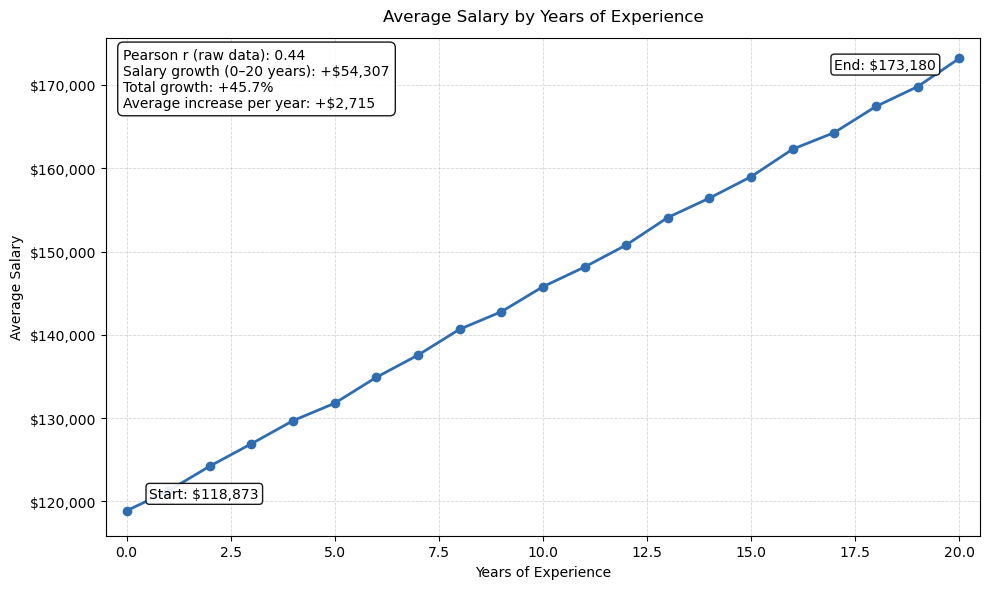

In [48]:
def dollar_format(x, pos):
    return f"${x:,.0f}"

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    experience_df["experience_years"],
    experience_df["average_salary"],
    marker="o",
    linewidth=2,
    color=palette["experience"]
)

ax.set_title("Average Salary by Years of Experience", pad=12)
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Average Salary")

ax.yaxis.set_major_formatter(FuncFormatter(dollar_format))
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

# Small margins around the plot
ax.set_xlim(-0.5, 20.5)
ax.set_ylim(
    experience_df["average_salary"].min() - 3000,
    experience_df["average_salary"].max() + 2500
)

first_y = experience_df["average_salary"].iloc[0]
last_y = experience_df["average_salary"].iloc[-1]

summary_text = (
    f"Pearson r (raw data): {pearson_r:.2f}\n"
    f"Salary growth (0–20 years): +${salary_growth:,.0f}\n"
    f"Total growth: +{salary_growth_pct:.1f}%\n"
    f"Average increase per year: +${avg_annual_growth:,.0f}"
)

# Main summary box
ax.text(
    0.02, 0.98,
    summary_text,
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

# Fixed corner labels instead of point labels
ax.text(
    0.05, 0.07,
    f"Start: ${first_y:,.0f}",
    transform=ax.transAxes,
    va="bottom",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.9)
)

ax.text(
    0.95, 0.96,
    f"End: ${last_y:,.0f}",
    transform=ax.transAxes,
    va="top",
    ha="right",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.savefig("assets/images/experience_salary.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The chart shows a clear upward relationship between experience and salary. Average pay rises steadily from entry-level profiles to highly experienced roles, with a total increase of more than $54,000 between 0 and 20 years of experience.

Using the raw joined data, the Pearson correlation indicates a moderate positive relationship between experience and salary. Overall, the visualization confirms that experience is one of the strongest salary drivers in the dataset.

## Visualization 2 — Education Level and Salary

The second visualization examines whether higher education levels are associated with higher salaries.

This directly supports the second hypothesis of the project: **higher education levels are associated with better pay**.

The chart compares average salary across education levels and highlights both the overall salary growth and the largest jump between consecutive academic stages.

In [49]:
education_query = """
SELECT
    jp.education_level,
    ROUND(AVG(sr.salary), 2) AS average_salary,
    COUNT(*) AS record_count
FROM salary_records sr
JOIN job_profiles jp
    ON sr.job_profile_id = jp.job_profile_id
GROUP BY jp.education_level
ORDER BY
    CASE
        WHEN jp.education_level = 'High School' THEN 1
        WHEN jp.education_level = 'Diploma' THEN 2
        WHEN jp.education_level = 'Bachelor' THEN 3
        WHEN jp.education_level = 'Master' THEN 4
        WHEN jp.education_level = 'PhD' THEN 5
    END;
"""

education_df = pd.read_sql(education_query, engine)

education_order = ["High School", "Diploma", "Bachelor", "Master", "PhD"]

education_df["education_level"] = pd.Categorical(
    education_df["education_level"].str.strip(),
    categories=education_order,
    ordered=True
)

education_df = (
    education_df
    .dropna(subset=["education_level"])
    .sort_values("education_level")
    .reset_index(drop=True)
)

education_start_salary = education_df["average_salary"].iloc[0]
education_end_salary = education_df["average_salary"].iloc[-1]

education_growth = education_end_salary - education_start_salary
education_growth_pct = (education_growth / education_start_salary) * 100

education_df["salary_increase"] = education_df["average_salary"].diff()

largest_jump_idx = education_df["salary_increase"].idxmax()
largest_jump_value = education_df.loc[largest_jump_idx, "salary_increase"]
largest_jump_from = education_df.loc[largest_jump_idx - 1, "education_level"]
largest_jump_to = education_df.loc[largest_jump_idx, "education_level"]

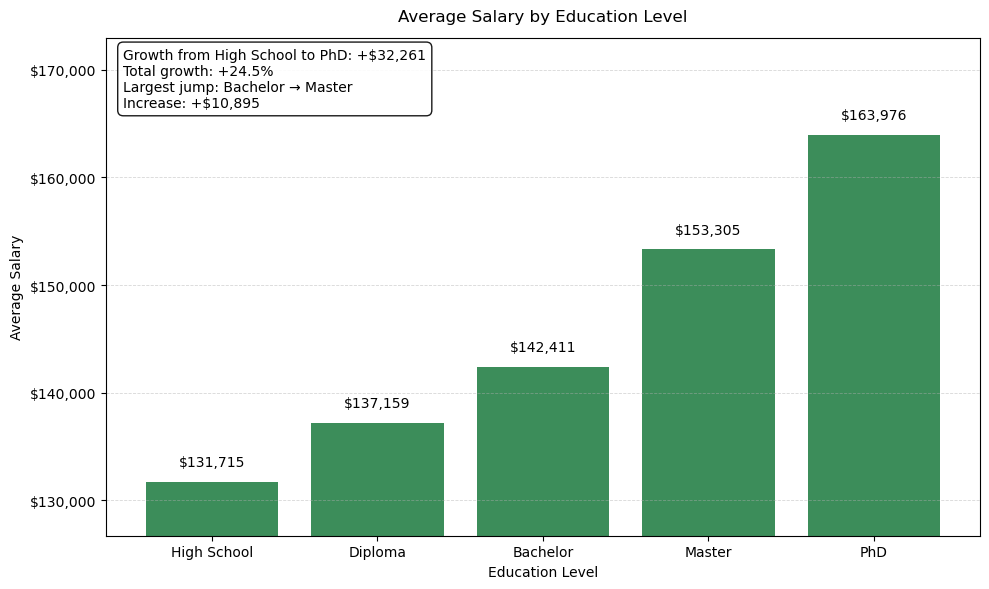

In [50]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

def dollar_format(x, pos):
    return f"${x:,.0f}"

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    education_df["education_level"].astype(str),
    education_df["average_salary"],
    color=palette["education"]
)

ax.set_title("Average Salary by Education Level", pad=12)
ax.set_xlabel("Education Level")
ax.set_ylabel("Average Salary")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_format))
ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

for bar, value in zip(bars, education_df["average_salary"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1200,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

summary_text = (
    f"Growth from High School to PhD: +${education_growth:,.0f}\n"
    f"Total growth: +{education_growth_pct:.1f}%\n"
    f"Largest jump: {largest_jump_from} → {largest_jump_to}\n"
    f"Increase: +${largest_jump_value:,.0f}"
)

ax.text(
    0.02, 0.98,
    summary_text,
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

ax.set_ylim(
    education_df["average_salary"].min() - 5000,
    education_df["average_salary"].max() + 9000
)

plt.tight_layout()
plt.savefig("assets/images/education_salary.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The chart shows a clear and consistent increase in average salary across education levels, from High School to PhD.

This pattern suggests a strong positive relationship between academic attainment and compensation. The largest gains appear at postgraduate stages, reinforcing the idea that advanced education is associated with a higher salary premium in the dataset.

## Visualization 3 — Remote Work and Salary

The third visualization explores whether work arrangement is associated with salary differences.

Because the average salaries across on-site, hybrid, and fully remote roles are relatively close in absolute terms, a dot plot provides a clearer comparison than a standard bar chart.

Using on-site work as the baseline, the chart highlights how hybrid and fully remote roles differ in average salary relative to the on-site benchmark.

In [51]:
remote_query = """
SELECT
    wc.remote_work,
    ROUND(AVG(sr.salary), 2) AS average_salary,
    COUNT(*) AS record_count
FROM salary_records sr
JOIN work_contexts wc
    ON sr.work_context_id = wc.work_context_id
GROUP BY wc.remote_work
ORDER BY
    CASE
        WHEN wc.remote_work = 'No' THEN 1
        WHEN wc.remote_work = 'Hybrid' THEN 2
        WHEN wc.remote_work = 'Yes' THEN 3
    END;
"""

remote_df = pd.read_sql(remote_query, engine)

remote_plot_df = remote_df.copy()

order = ["No", "Hybrid", "Yes"]
remote_plot_df["remote_work"] = pd.Categorical(
    remote_plot_df["remote_work"].str.strip(),
    categories=order,
    ordered=True
)

remote_plot_df = (
    remote_plot_df
    .dropna(subset=["remote_work"])
    .sort_values("remote_work")
    .reset_index(drop=True)
)

baseline_salary = remote_plot_df.loc[
    remote_plot_df["remote_work"] == "No", "average_salary"
].iloc[0]

remote_plot_df["salary_diff_pct"] = (
    (remote_plot_df["average_salary"] - baseline_salary) / baseline_salary
) * 100

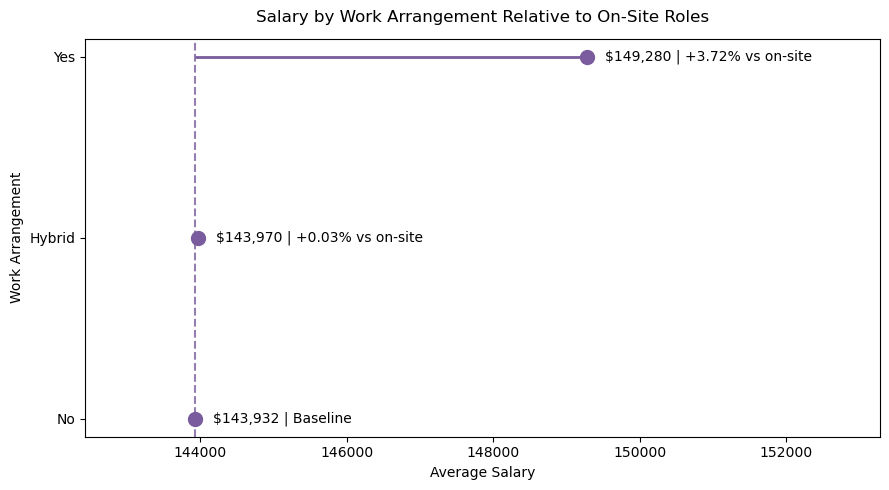

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))

y_pos = range(len(remote_plot_df))

ax.axvline(
    baseline_salary,
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    color=palette["remote"]
)

ax.hlines(
    y=y_pos,
    xmin=baseline_salary,
    xmax=remote_plot_df["average_salary"],
    linewidth=2,
    color=palette["remote"]
)

ax.scatter(
    remote_plot_df["average_salary"],
    y_pos,
    s=100,
    zorder=3,
    color=palette["remote"]
)

for i, row in remote_plot_df.iterrows():
    if row["remote_work"] == "No":
        label = f"${row['average_salary']:,.0f} | Baseline"
    else:
        label = f"${row['average_salary']:,.0f} | {row['salary_diff_pct']:+.2f}% vs on-site"

    ax.text(
        row["average_salary"] + 250,
        i,
        label,
        va="center"
    )

ax.set_yticks(list(y_pos))
ax.set_yticklabels(remote_plot_df["remote_work"].astype(str))
ax.set_xlabel("Average Salary")
ax.set_ylabel("Work Arrangement")
ax.set_title("Salary by Work Arrangement Relative to On-Site Roles", pad=12)

xmin = remote_plot_df["average_salary"].min() - 1500
xmax = remote_plot_df["average_salary"].max() + 4000
ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.savefig("assets/images/remote_work_salary.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The chart shows that hybrid roles are almost identical to on-site positions in average salary, while fully remote roles display a clear positive difference relative to the on-site baseline.

This suggests that remote work is associated with a moderate salary advantage, although the effect is mainly driven by fully remote positions rather than hybrid work arrangements.

## Visualization 4 — Industry and Salary

The fourth visualization examines whether industry is associated with meaningful salary differences.

This directly supports the fourth hypothesis of the project: **industry may influence salary**.

Because the differences across industries are relatively small, a ranked dot plot provides a clearer comparison than a standard bar chart. The goal is not only to show the ranking, but also to assess whether the variation is strong enough to matter in practice.

In [53]:
industry_query = """
SELECT
    wc.industry,
    ROUND(AVG(sr.salary), 2) AS average_salary,
    COUNT(*) AS record_count
FROM salary_records sr
JOIN work_contexts wc
    ON sr.work_context_id = wc.work_context_id
GROUP BY wc.industry
ORDER BY average_salary DESC;
"""

industry_df = pd.read_sql(industry_query, engine)
industry_df

,industry,average_salary,record_count
0,Education,145993.56,24889
1,Media,145891.27,25034
2,Telecom,145876.51,24859
3,Technology,145863.81,24903
4,Finance,145801.64,25393
5,Healthcare,145760.00,24898
6,Government,145613.87,24901
7,Manufacturing,145530.60,25024
8,Consulting,145451.64,25258
9,Retail,145399.70,24841


In [54]:
industry_top = industry_df["average_salary"].max()
industry_bottom = industry_df["average_salary"].min()
industry_range = industry_top - industry_bottom

top_industry = industry_df.iloc[0]["industry"]
bottom_industry = industry_df.iloc[-1]["industry"]

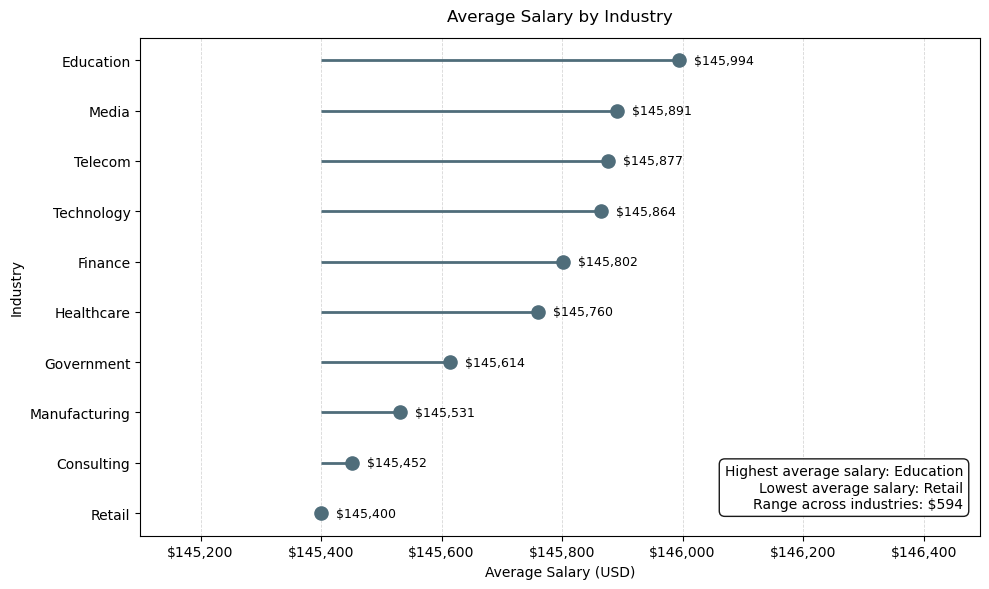

In [55]:
def dollar_format(x, pos):
    return f"${x:,.0f}"

fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal lines from the minimum salary to each point
xmin = industry_df["average_salary"].min()
ax.hlines(
    y=industry_df["industry"],
    xmin=xmin,
    xmax=industry_df["average_salary"],
    color=palette["industry"],
    linewidth=2
)

# Points
ax.scatter(
    industry_df["average_salary"],
    industry_df["industry"],
    s=90,
    color=palette["industry"],
    zorder=3
)

ax.invert_yaxis()

ax.set_title("Average Salary by Industry", pad=12)
ax.set_xlabel("Average Salary (USD)")
ax.set_ylabel("Industry")
ax.xaxis.set_major_formatter(FuncFormatter(dollar_format))
ax.grid(True, axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

# Add labels to each point
for i, value in enumerate(industry_df["average_salary"]):
    ax.text(
        value + 25,
        i,
        f"${value:,.0f}",
        va="center",
        fontsize=9
    )

summary_text = (
    f"Highest average salary: {top_industry}\n"
    f"Lowest average salary: {bottom_industry}\n"
    f"Range across industries: ${industry_range:,.0f}"
)

ax.text(
    0.98, 0.05,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

ax.set_xlim(
    industry_df["average_salary"].min() - 300,
    industry_df["average_salary"].max() + 500
)

plt.tight_layout()
plt.savefig("assets/images/industry_salary.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The chart shows that average salary differences across industries are minimal, even when a ranking is established.

Although some sectors appear slightly above others, the total range is very small relative to the salary scale. This suggests that industry is not a strong salary differentiator in the dataset, especially when compared with factors such as experience, education, or job title.

## Visualization 5 — Salary by Job Title

This visualization explores how average salary differs across job titles.

Unlike industry, which showed only minor variation in salary levels, job title appears to be a much stronger differentiator in the dataset.

The goal of this chart is to compare salary levels across roles and identify which positions are associated with the highest and lowest average pay.

In [56]:
job_title_query = """
SELECT
    jp.job_title,
    ROUND(AVG(sr.salary), 2) AS average_salary,
    COUNT(*) AS record_count
FROM salary_records sr
JOIN job_profiles jp
    ON sr.job_profile_id = jp.job_profile_id
GROUP BY jp.job_title
ORDER BY average_salary DESC;
"""

job_title_df = pd.read_sql(job_title_query, engine)
job_title_df["job_title"] = job_title_df["job_title"].str.strip()

job_title_df.head()

,job_title,average_salary,record_count
0,AI Engineer,173498.48,20945
1,Machine Learning Engineer,163022.50,20677
2,Product Manager,157594.93,20950
3,Cloud Engineer,152102.54,20686
4,DevOps Engineer,149959.27,20889


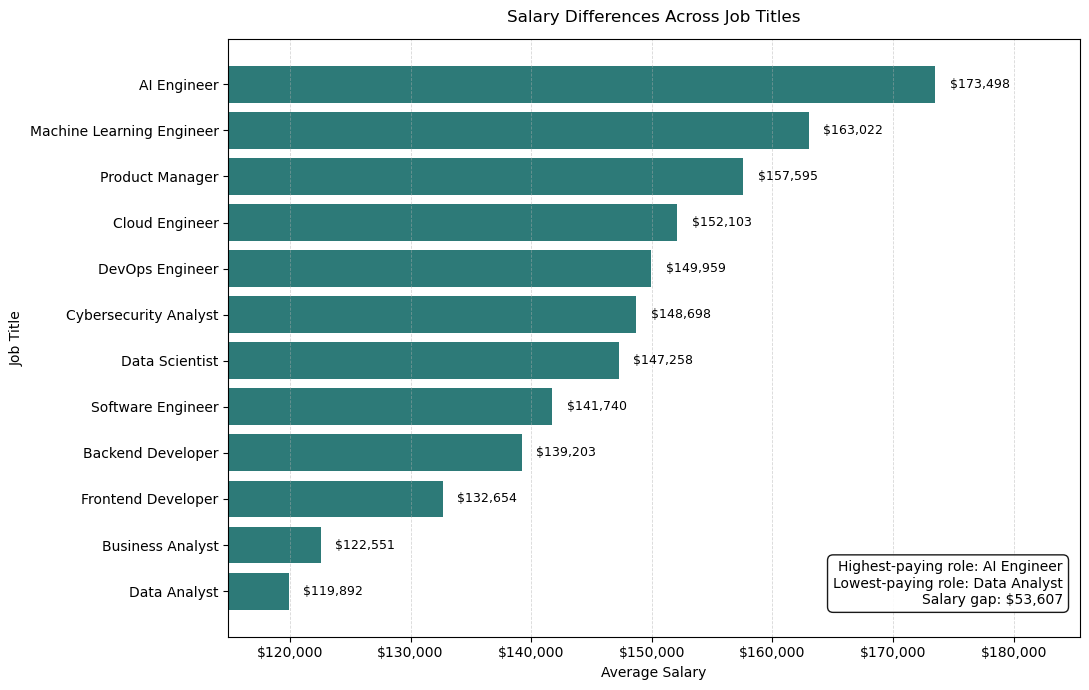

In [57]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

job_title_query = """
SELECT
    jp.job_title,
    ROUND(AVG(sr.salary), 2) AS average_salary,
    COUNT(*) AS record_count
FROM salary_records sr
JOIN job_profiles jp
    ON sr.job_profile_id = jp.job_profile_id
GROUP BY jp.job_title
ORDER BY average_salary DESC;
"""

job_title_df = pd.read_sql(job_title_query, engine)
job_title_df["job_title"] = job_title_df["job_title"].str.strip()

def dollar_format(x, pos):
    return f"${x:,.0f}"

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    job_title_df["job_title"],
    job_title_df["average_salary"],
    color=palette["job_title"]
)
ax.invert_yaxis()

ax.set_title("Salary Differences Across Job Titles", pad=12)
ax.set_xlabel("Average Salary")
ax.set_ylabel("Job Title")
ax.xaxis.set_major_formatter(FuncFormatter(dollar_format))
ax.grid(True, axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

for i, value in enumerate(job_title_df["average_salary"]):
    ax.text(
        value + 1200,
        i,
        f"${value:,.0f}",
        va="center",
        fontsize=9
    )

top_role = job_title_df.iloc[0]["job_title"]
bottom_role = job_title_df.iloc[-1]["job_title"]
salary_gap = job_title_df["average_salary"].iloc[0] - job_title_df["average_salary"].iloc[-1]

summary_text = (
    f"Highest-paying role: {top_role}\n"
    f"Lowest-paying role: {bottom_role}\n"
    f"Salary gap: ${salary_gap:,.0f}"
)

ax.text(
    0.98, 0.05,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

ax.set_xlim(
    job_title_df["average_salary"].min() - 5000,
    job_title_df["average_salary"].max() + 12000
)

plt.tight_layout()
plt.savefig("assets/images/job_title_salary.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

This chart shows that salary differences across job titles are substantial and much more pronounced than the variation observed across industries.

AI Engineer, Machine Learning Engineer, and Product Manager appear at the top of the salary ranking, while Business Analyst and Data Analyst are positioned at the lower end. Overall, the visualization confirms that job title is one of the strongest salary differentiators in the dataset.

## Visualization 6 — Education Effect Within Selected Job Titles

The final visualization explores whether the relationship between education and salary remains visible within specific professions.

Rather than using all job titles at once, the chart focuses on a small set of representative roles selected from the SQL salary ranking.

This allows us to assess whether higher education is associated with higher pay not only overall, but also within individual job titles.

In [58]:
job_education_query = """
SELECT
    jp.job_title,
    jp.education_level,
    ROUND(AVG(sr.salary), 2) AS average_salary,
    COUNT(*) AS record_count
FROM salary_records sr
JOIN job_profiles jp
    ON sr.job_profile_id = jp.job_profile_id
GROUP BY jp.job_title, jp.education_level
ORDER BY jp.job_title,
    CASE
        WHEN jp.education_level = 'High School' THEN 1
        WHEN jp.education_level = 'Diploma' THEN 2
        WHEN jp.education_level = 'Bachelor' THEN 3
        WHEN jp.education_level = 'Master' THEN 4
        WHEN jp.education_level = 'PhD' THEN 5
    END;
"""

job_education_df = pd.read_sql(job_education_query, engine)
job_education_df.head()

,job_title,education_level,average_salary,record_count
0,AI Engineer,High School,159405.10,4211
1,AI Engineer,Diploma,164761.71,4178
2,AI Engineer,Bachelor,170325.17,4212
3,AI Engineer,Master,181456.01,4192
4,AI Engineer,PhD,191768.58,4152


In [59]:
selected_roles = [
    "AI Engineer",
    "Machine Learning Engineer",
    "Product Manager",
    "Software Engineer",
    "Data Analyst"
]

education_order = ["High School", "Diploma", "Bachelor", "Master", "PhD"]

selected_job_education_df = job_education_df[
    job_education_df["job_title"].isin(selected_roles)
].copy()

selected_job_education_df["education_level"] = pd.Categorical(
    selected_job_education_df["education_level"],
    categories=education_order,
    ordered=True
)

selected_job_education_df = selected_job_education_df.sort_values(
    ["job_title", "education_level"]
)

selected_job_education_df

,job_title,education_level,average_salary,record_count
0,AI Engineer,High School,159405.10,4211
1,AI Engineer,Diploma,164761.71,4178
2,AI Engineer,Bachelor,170325.17,4212
3,AI Engineer,Master,181456.01,4192
4,AI Engineer,PhD,191768.58,4152
25,Data Analyst,High School,105992.61,4088
26,Data Analyst,Diploma,111354.09,4126
27,Data Analyst,Bachelor,116160.93,4206
28,Data Analyst,Master,127668.25,4161
29,Data Analyst,PhD,138094.79,4141


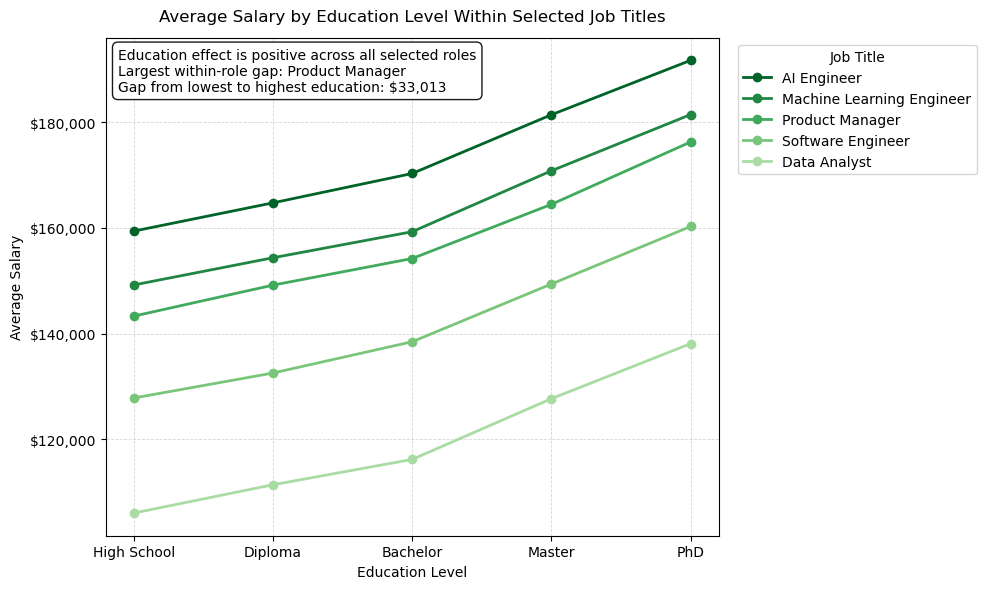

In [60]:
import numpy as np
from matplotlib.ticker import FuncFormatter

def dollar_format(x, pos):
    return f"${x:,.0f}"

# Rank selected roles by overall average salary (lowest -> highest)
role_salary_rank = (
    selected_job_education_df.groupby("job_title")["average_salary"]
    .mean()
    .sort_values()
)

# Green gradient: lighter for lower-paying roles, darker for higher-paying roles
colors = plt.cm.Greens(np.linspace(0.35, 0.9, len(role_salary_rank)))
role_colors = dict(zip(role_salary_rank.index, colors))

# Plot order in the legend: highest-paying first
plot_order = role_salary_rank.sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

for role in plot_order:
    role_df = selected_job_education_df[
        selected_job_education_df["job_title"] == role
    ]
    ax.plot(
        role_df["education_level"],
        role_df["average_salary"],
        marker="o",
        linewidth=2,
        label=role,
        color=role_colors[role]
    )

ax.set_title("Average Salary by Education Level Within Selected Job Titles", pad=12)
ax.set_xlabel("Education Level")
ax.set_ylabel("Average Salary")
ax.yaxis.set_major_formatter(FuncFormatter(dollar_format))
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

role_gap = (
    selected_job_education_df.groupby("job_title")["average_salary"].max()
    - selected_job_education_df.groupby("job_title")["average_salary"].min()
).sort_values(ascending=False)

largest_role_gap = role_gap.index[0]
largest_role_gap_value = role_gap.iloc[0]

summary_text = (
    f"Education effect is positive across all selected roles\n"
    f"Largest within-role gap: {largest_role_gap}\n"
    f"Gap from lowest to highest education: ${largest_role_gap_value:,.0f}"
)

ax.text(
    0.02, 0.98,
    summary_text,
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

ax.legend(title="Job Title", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("assets/images/education_within_roles.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The chart shows that the positive relationship between education and salary remains visible within every selected role.

This is important because it confirms that the education effect observed in the overall analysis is not simply driven by job title composition. Higher education is associated with higher pay not only across the dataset as a whole, but also within individual professions.